# Multi-Omics EDA v3 — Research-Grade Preprocessing
### TCGA Pan-Cancer: mRNA + CNV + Mutation + DNA Methylation (450K)
**Data specs (from Xena hub):**
- mRNA: ~11K samples × ~20K genes
- CNV: ~10K samples × ~23K genes  
- Mutation: ~9K samples × ~40K genes
- Methylation: 9,639 samples × **396,066 probes** (~40GB raw TSV)

**Key design decisions:**
- Methylation loaded in chunks of 10K probes to avoid OOM on 30GB Kaggle RAM
- Missing values: probe-wise median (NOT 0, NOT mean — see cell comments)
- All scaling/normalization happens in training notebook on train split only


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.size']   = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '═'*65)
    print(f'  {title}')
    print('═'*65)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM usage: {mb:.1f} MB | shape: {df.shape}')

# ═══════════════════════════════════════════════════════════════
#  FILE PATHS — update to your Kaggle input paths
# ═══════════════════════════════════════════════════════════════
BASE = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data'

path_mrna  = f'{BASE}/EBAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
path_cnv   = f'{BASE}/Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes'
path_mut   = f'{BASE}/mc3.v0.2.8.PUBLIC.nonsilentGene.xena'
path_pheno = f'{BASE}/TCGA_phenotype_denseDataOnlyDownload.tsv'
# 450K methylation (the 40GB file from Xena PANCAN atlas hub)
path_meth  = f'{BASE}/jhu-usc.edu_PANCAN_HumanMethylation450.betaValue_whitelisted.tsv.synapse_download_5096262.xena/jhu-usc.edu_PANCAN_HumanMethylation450.betaValue_whitelisted.tsv.synapse_download_5096262.xena'

# ── CONFIG ──────────────────────────────────────────────────────
# Set True once methylation file is uploaded to Kaggle dataset
INCLUDE_METHYLATION = True

# Methylation chunk size (probes per chunk).
# 10000 probes × 9639 samples × 4 bytes ≈ 385 MB per chunk (safe for 30GB RAM)
# Reduce to 5000 if you still OOM during processing
METH_CHUNK_SIZE = 10_000

# Probe missingness threshold: drop probes with > this fraction of NaN
PROBE_NAN_THRESH = 0.30

# Sample missingness threshold: drop samples with > this fraction of NaN
SAMPLE_NAN_THRESH = 0.50

# Bottom-variance quantile to remove from mRNA (removes uninformative genes)
MRNA_VAR_QUANTILE  = 0.10

# Minimum samples per cancer class to keep
MIN_CLASS_SAMPLES = 10

print('Setup complete.')
print(f'INCLUDE_METHYLATION = {INCLUDE_METHYLATION}')
print(f'Methylation chunk size = {METH_CHUNK_SIZE:,} probes')


Setup complete.
INCLUDE_METHYLATION = True
Methylation chunk size = 10,000 probes



═════════════════════════════════════════════════════════════════
  1. PHENOTYPE EDA & CLEANING
═════════════════════════════════════════════════════════════════
Raw phenotype shape: (12804, 4)
Columns: ['sample', 'sample_type_id', 'sample_type', '_primary_disease']
Sample types:
sample_type
Primary Tumor                                      10593
Solid Tissue Normal                                 1475
Metastatic                                           396
Primary Blood Derived Cancer - Peripheral Blood      200
Recurrent Tumor                                       56
Additional - New Primary                              11
Additional Metastatic                                  1


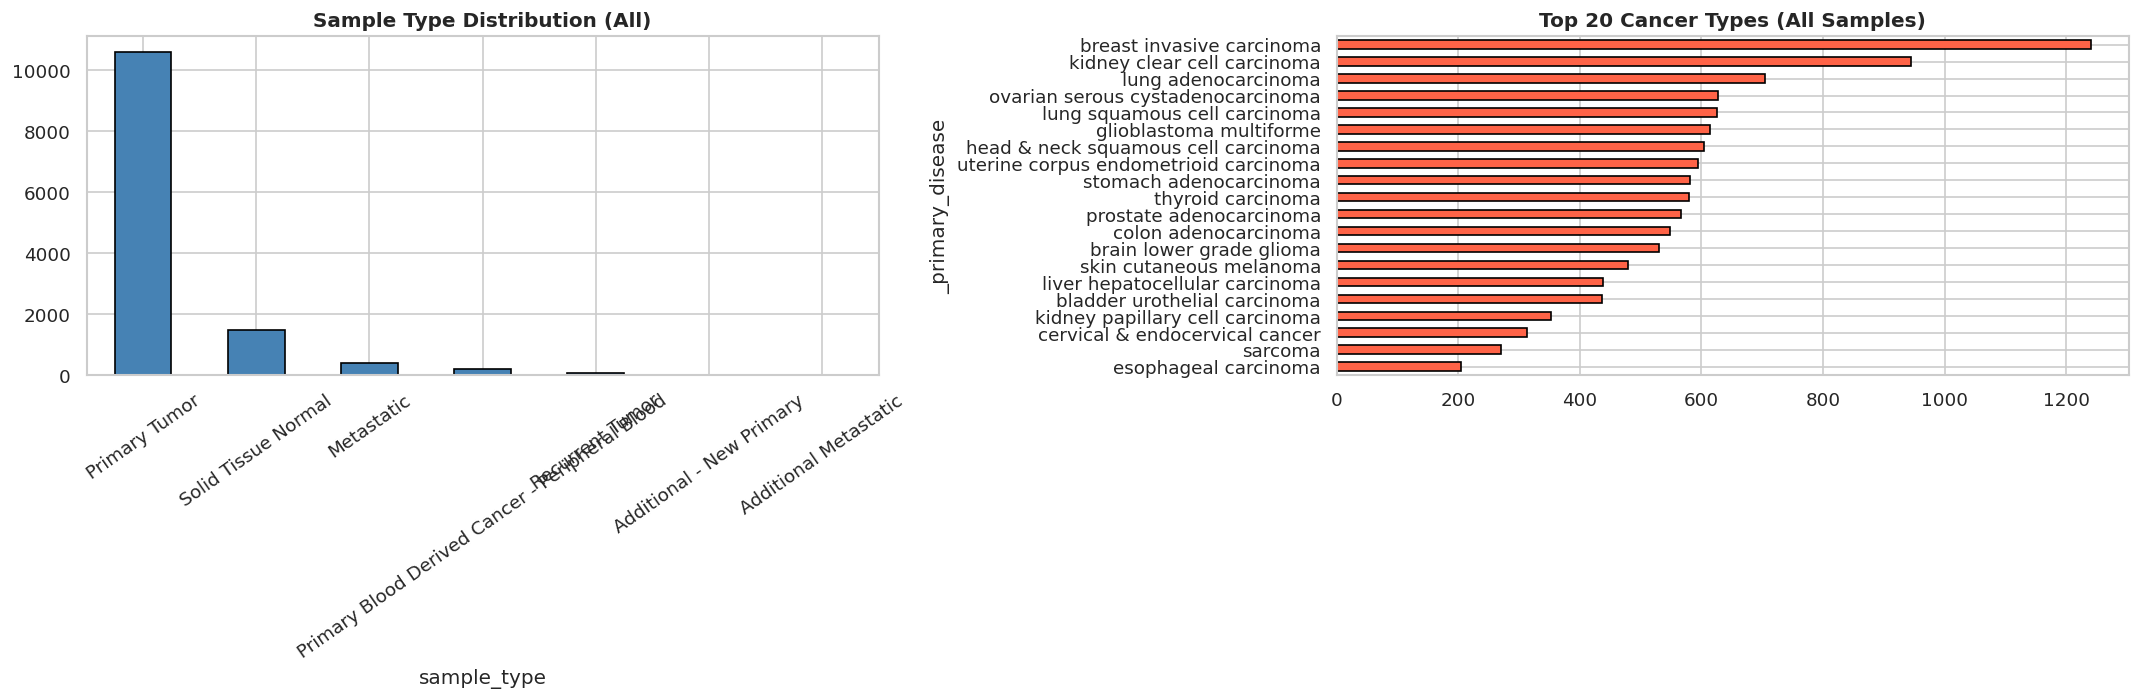


After filtering to Primary Tumor + >= 10 samples/class:
  Patients: 10593
  Cancer types kept: 32


91

In [2]:
section('1. PHENOTYPE EDA & CLEANING')

pheno_raw = pd.read_csv(path_pheno, sep='\t')
print(f'Raw phenotype shape: {pheno_raw.shape}')
print(f'Columns: {list(pheno_raw.columns)}')
print(f'Sample types:\n{pheno_raw["sample_type"].value_counts().to_string()}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pheno_raw['sample_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Sample Type Distribution (All)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

pheno_raw['_primary_disease'].value_counts().head(20).plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Top 20 Cancer Types (All Samples)', fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

# ── Keep Primary Tumor only ──────────────────────────────────────────────
pheno = pheno_raw[pheno_raw['sample_type'] == 'Primary Tumor'].copy()
pheno.index = pheno['sample'].str[:15]
pheno = pheno[~pheno.index.duplicated(keep='first')]

# ── Drop extremely rare classes ──────────────────────────────────────────
type_counts  = pheno['_primary_disease'].value_counts()
valid_types  = type_counts[type_counts >= MIN_CLASS_SAMPLES].index
dropped_types = type_counts[type_counts < MIN_CLASS_SAMPLES].index.tolist()
pheno        = pheno[pheno['_primary_disease'].isin(valid_types)]

print(f'\nAfter filtering to Primary Tumor + >= {MIN_CLASS_SAMPLES} samples/class:')
print(f'  Patients: {len(pheno)}')
print(f'  Cancer types kept: {pheno["_primary_disease"].nunique()}')
if dropped_types:
    print(f'  Dropped rare types: {dropped_types}')

valid_patients_pheno = set(pheno.index)
del pheno_raw; gc.collect()



═════════════════════════════════════════════════════════════════
  2. mRNA EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading mRNA (transposing — genes as rows in raw file)...
Cleaned mRNA shape: (11060, 20530)
  [mRNA] RAM usage: 909.0 MB | shape: (11060, 20530)

mRNA missing values:
  Genes with any NaN:   4196 / 20530
  Samples with any NaN: 1750 / 11060
  Max NaN% per gene:    15.82%


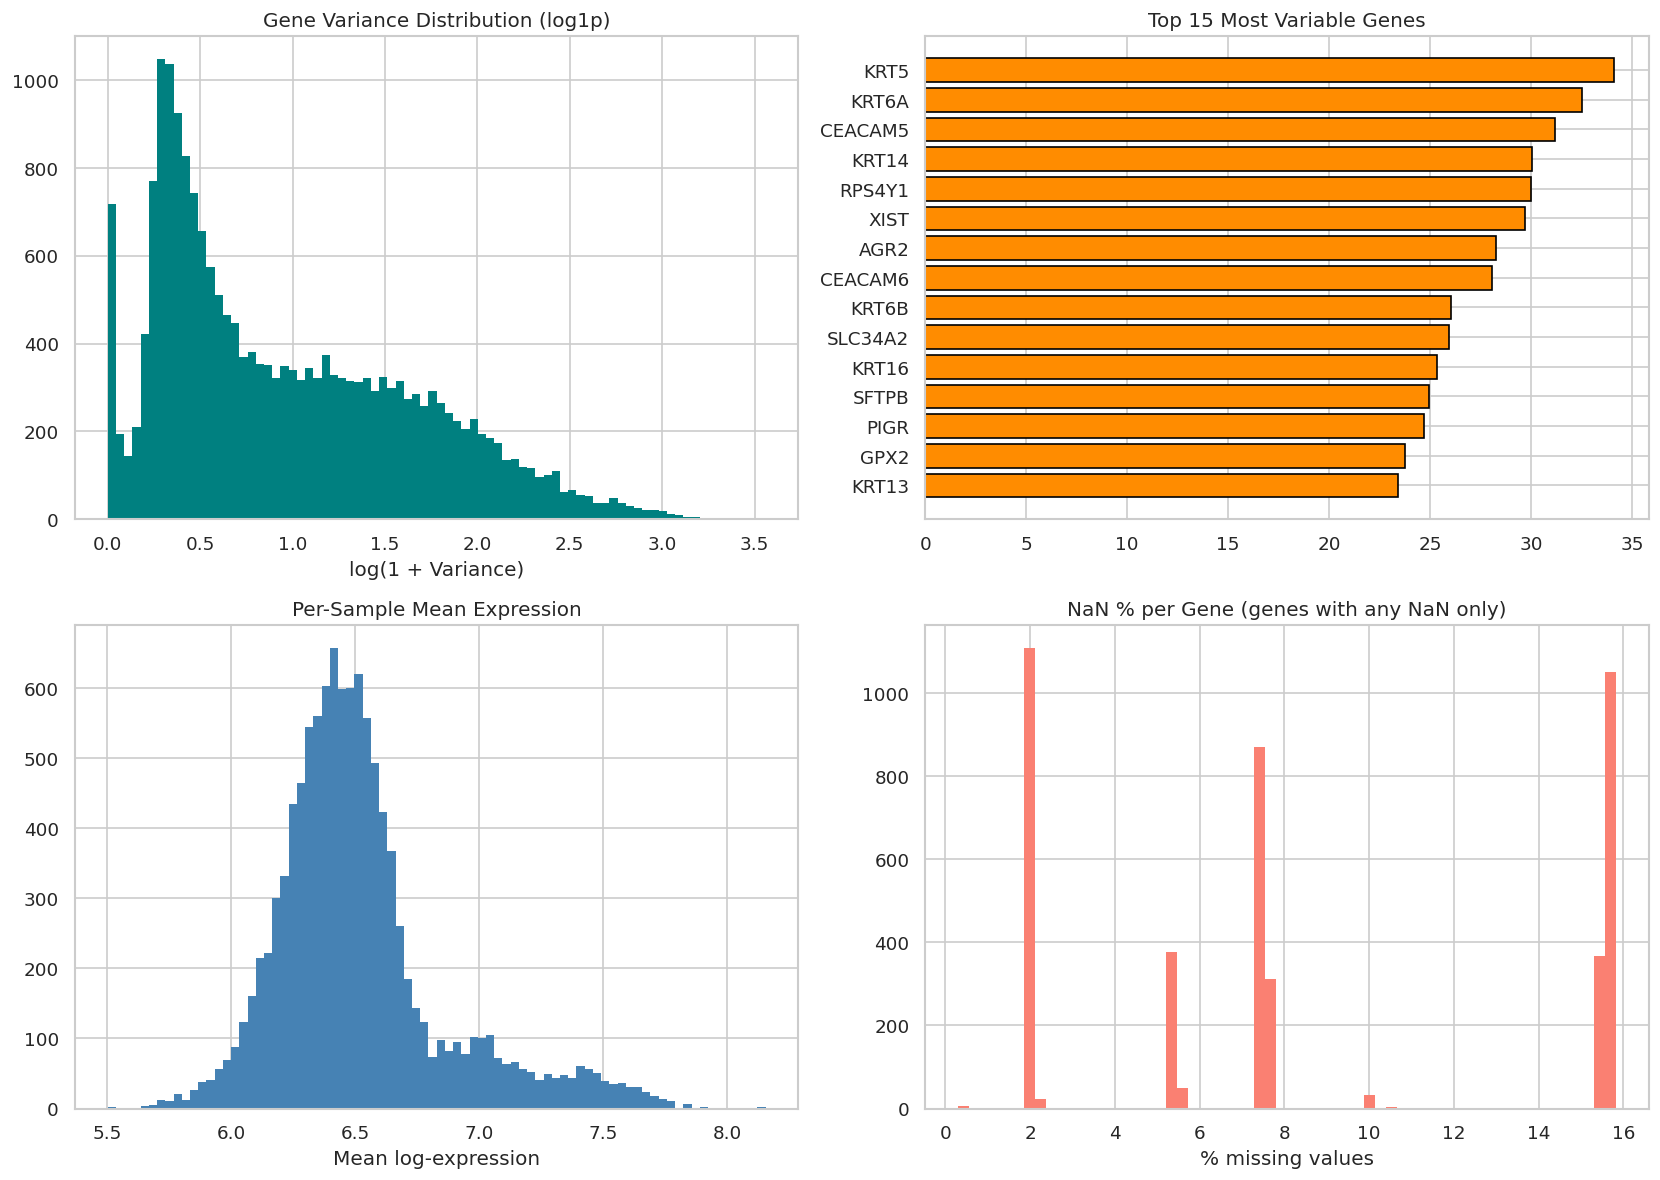

8362

In [3]:
section('2. mRNA EDA & CLEANING')

print('Loading mRNA (transposing — genes as rows in raw file)...')
mrna = pd.read_csv(path_mrna, sep='\t', index_col=0).T
mrna.index   = mrna.index.str[:15]
mrna         = mrna[~mrna.index.duplicated(keep='first')]
mrna.columns = [str(c).split('|')[0] for c in mrna.columns]
mrna         = mrna.loc[:, ~mrna.columns.duplicated(keep='first')]
mrna         = mrna.astype(np.float32)
print(f'Cleaned mRNA shape: {mrna.shape}')
mem_usage(mrna, 'mRNA')

# ── EDA stats ────────────────────────────────────────────────────────────
gene_var    = mrna.var(axis=0)
sample_mean = mrna.mean(axis=1)
nan_per_gene  = mrna.isnull().mean(axis=0)
nan_per_sample = mrna.isnull().mean(axis=1)

print(f'\nmRNA missing values:')
print(f'  Genes with any NaN:   {(nan_per_gene > 0).sum()} / {mrna.shape[1]}')
print(f'  Samples with any NaN: {(nan_per_sample > 0).sum()} / {mrna.shape[0]}')
print(f'  Max NaN% per gene:    {nan_per_gene.max()*100:.2f}%')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(np.log1p(gene_var), bins=80, color='teal', edgecolor='none')
axes[0,0].set_title('Gene Variance Distribution (log1p)')
axes[0,0].set_xlabel('log(1 + Variance)')

top15_var = gene_var.nlargest(15)
axes[0,1].barh(top15_var.index, top15_var.values, color='darkorange', edgecolor='black')
axes[0,1].set_title('Top 15 Most Variable Genes')
axes[0,1].invert_yaxis()

axes[1,0].hist(sample_mean, bins=80, color='steelblue', edgecolor='none')
axes[1,0].set_title('Per-Sample Mean Expression')
axes[1,0].set_xlabel('Mean log-expression')

axes[1,1].hist(nan_per_gene[nan_per_gene > 0] * 100, bins=60, color='salmon', edgecolor='none')
axes[1,1].set_title('NaN % per Gene (genes with any NaN only)')
axes[1,1].set_xlabel('% missing values')

plt.tight_layout(); plt.show()

valid_patients_mrna = set(mrna.index)
valid_genes_mrna    = set(mrna.columns)
gc.collect()



═════════════════════════════════════════════════════════════════
  3. CNV EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading CNV...
Cleaned CNV shape: (10845, 23705)
CNV missing values: 0 → filling with 0 (diploid normal)
  [CNV] RAM usage: 258.0 MB | shape: (10845, 23705)


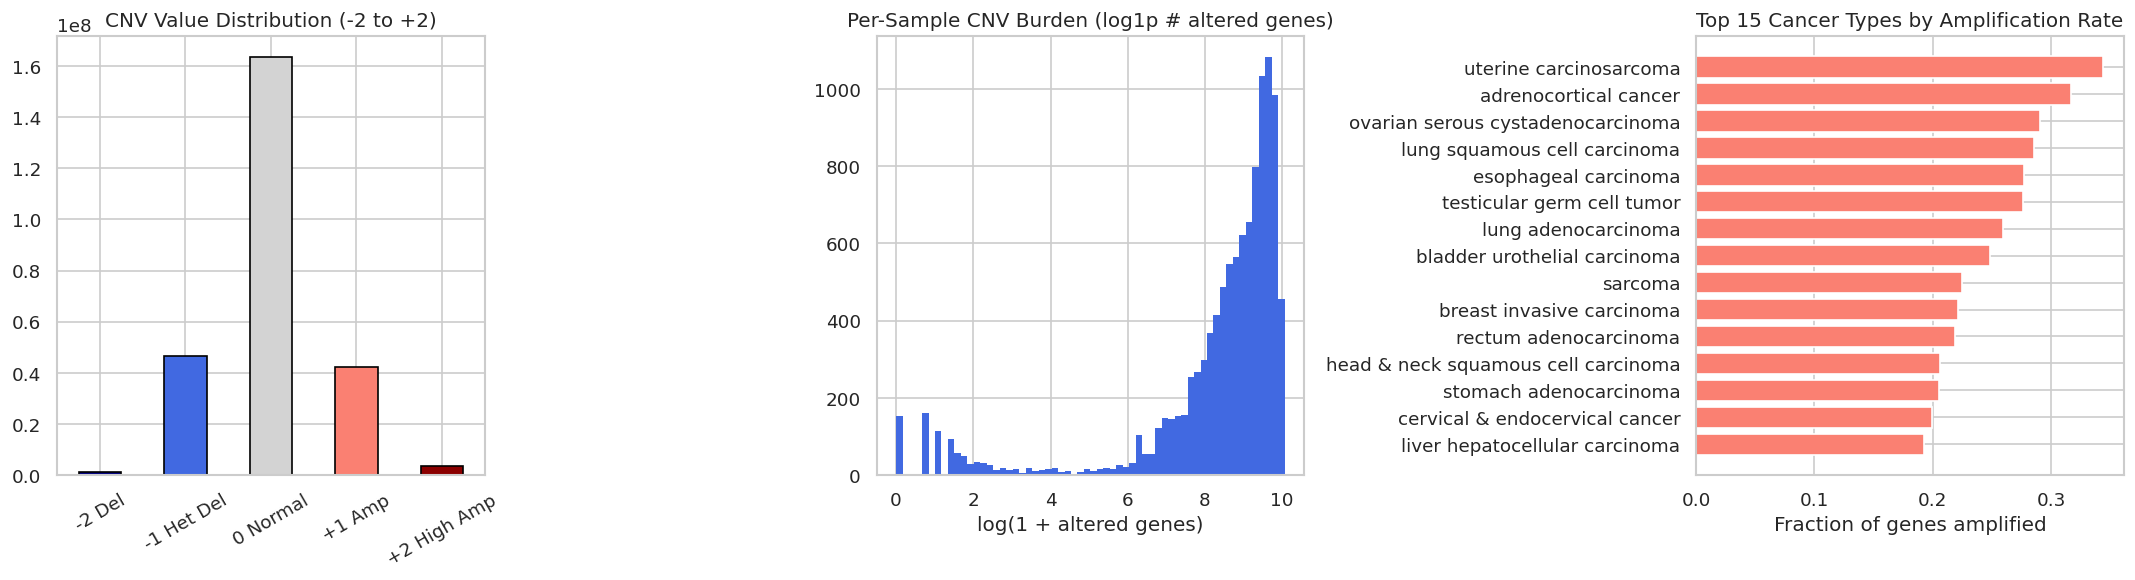

24817

In [4]:
section('3. CNV EDA & CLEANING')

print('Loading CNV...')
cnv = pd.read_csv(path_cnv, sep='\t', index_col=0).T
cnv.index   = cnv.index.str[:15]
cnv         = cnv[~cnv.index.duplicated(keep='first')]
cnv.columns = [str(c).split('|')[0] for c in cnv.columns]
cnv         = cnv.loc[:, ~cnv.columns.duplicated(keep='first')]
print(f'Cleaned CNV shape: {cnv.shape}')

# CNV has discrete values: -2, -1, 0, +1, +2
# Missing = normal diploid (0) — standard in TCGA CNV literature
nan_count = cnv.isnull().sum().sum()
print(f'CNV missing values: {nan_count:,} → filling with 0 (diploid normal)')
cnv = cnv.fillna(0).astype(np.int8)   # int8 saves 87% RAM vs float64
mem_usage(cnv, 'CNV')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

val_counts = cnv.stack().value_counts().sort_index()
colors = ['navy','royalblue','lightgray','salmon','darkred']
val_counts.plot(kind='bar', color=colors, edgecolor='black', ax=axes[0])
axes[0].set_title('CNV Value Distribution (-2 to +2)')
axes[0].set_xticklabels(['-2 Del','-1 Het Del','0 Normal','+1 Amp','+2 High Amp'], rotation=30)

sample_cnv_burden = (cnv != 0).sum(axis=1)
axes[1].hist(np.log1p(sample_cnv_burden), bins=60, color='royalblue', edgecolor='none')
axes[1].set_title('Per-Sample CNV Burden (log1p # altered genes)')
axes[1].set_xlabel('log(1 + altered genes)')

# Amp vs deletion ratio per cancer type
cnv_labeled = cnv.copy()
cnv_labeled.index = cnv_labeled.index.map(lambda x: pheno.loc[x, '_primary_disease']
                                           if x in pheno.index else 'Unknown')
amp_rate = (cnv_labeled > 0).mean(axis=1).groupby(level=0).mean()
del_rate = (cnv_labeled < 0).mean(axis=1).groupby(level=0).mean()
amp_rate = amp_rate.sort_values(ascending=False).head(15)
axes[2].barh(amp_rate.index, amp_rate.values, color='salmon', label='Amplification')
axes[2].set_title('Top 15 Cancer Types by Amplification Rate')
axes[2].invert_yaxis(); axes[2].set_xlabel('Fraction of genes amplified')
plt.tight_layout(); plt.show()

valid_patients_cnv = set(cnv.index)
valid_genes_cnv    = set(cnv.columns)
del cnv_labeled; gc.collect()



═════════════════════════════════════════════════════════════════
  4. MUTATION EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading Mutation...
Cleaned Mutation shape: (9104, 40543)
Mutation missing values: 0 → filling with 0 (wildtype)
Sparsity (fraction zeros): 99.6%
  [Mutation] RAM usage: 370.0 MB | shape: (9104, 40543)


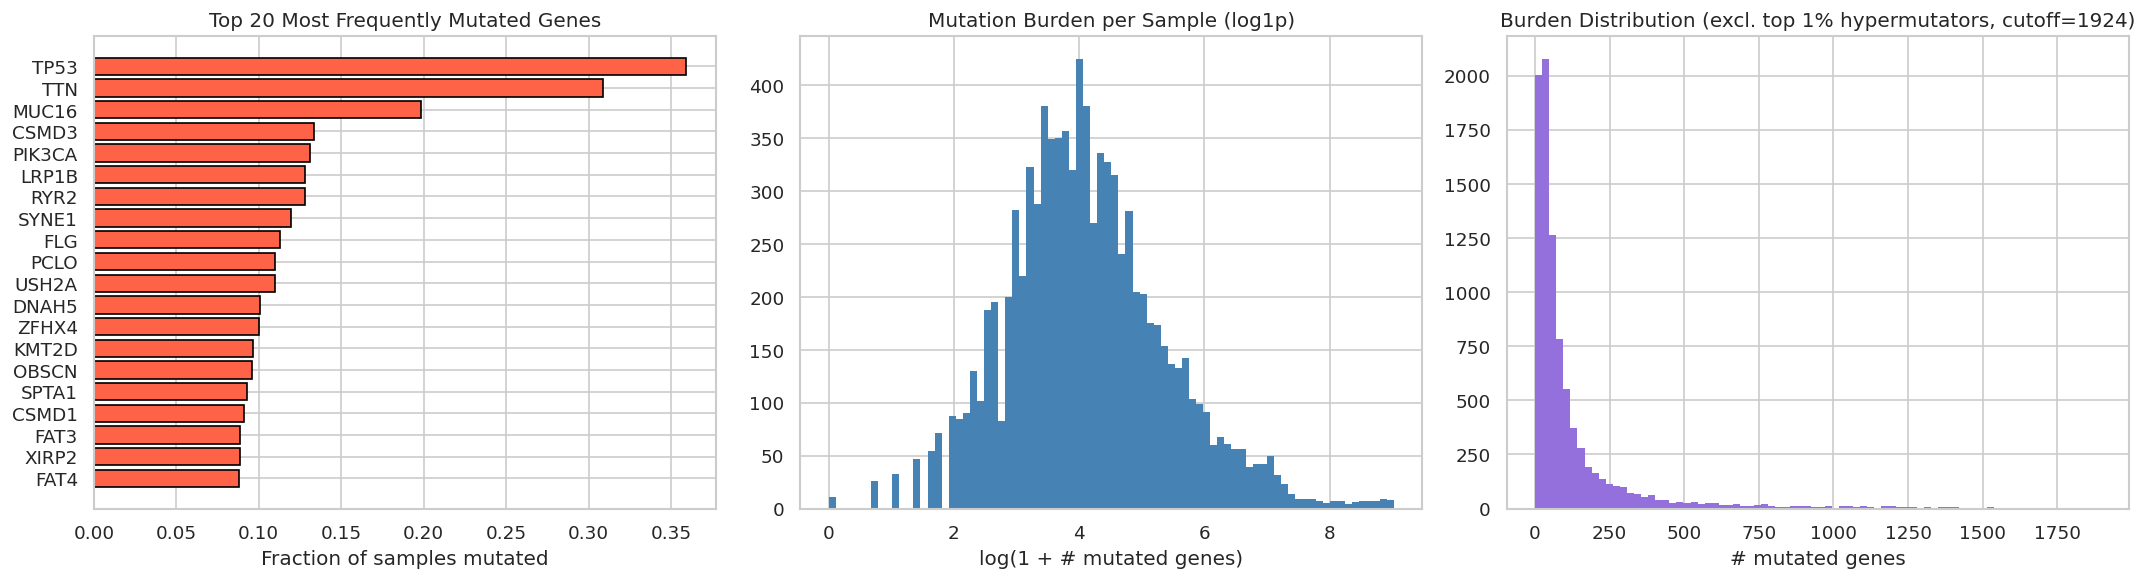

Hypermutated samples (>99th percentile, >1924 genes): 92


13501

In [5]:
section('4. MUTATION EDA & CLEANING')

print('Loading Mutation...')
mut = pd.read_csv(path_mut, sep='\t', index_col=0).T
mut.index   = mut.index.str[:15]
mut         = mut[~mut.index.duplicated(keep='first')]
mut.columns = [str(c).split('|')[0] for c in mut.columns]
mut         = mut.loc[:, ~mut.columns.duplicated(keep='first')]
print(f'Cleaned Mutation shape: {mut.shape}')

# Mutation is binary (0=wildtype, 1=mutated). Missing = wildtype (0).
nan_count = mut.isnull().sum().sum()
sparsity  = (mut == 0).mean().mean() if nan_count == 0 else (mut.fillna(0) == 0).mean().mean()
print(f'Mutation missing values: {nan_count:,} → filling with 0 (wildtype)')
print(f'Sparsity (fraction zeros): {sparsity*100:.1f}%')
mut = mut.fillna(0).astype(np.int8)
mem_usage(mut, 'Mutation')

mut_rate      = mut.mean(axis=0)
sample_burden = mut.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top20_mut = mut_rate.nlargest(20)
axes[0].barh(top20_mut.index, top20_mut.values, color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Most Frequently Mutated Genes')
axes[0].set_xlabel('Fraction of samples mutated')
axes[0].invert_yaxis()

axes[1].hist(np.log1p(sample_burden), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Mutation Burden per Sample (log1p)')
axes[1].set_xlabel('log(1 + # mutated genes)')

# High-burden outliers (hypermutated tumors)
q99 = sample_burden.quantile(0.99)
axes[2].hist(sample_burden[sample_burden <= q99], bins=80, color='mediumpurple', edgecolor='none')
axes[2].set_title(f'Burden Distribution (excl. top 1% hypermutators, cutoff={q99:.0f})')
axes[2].set_xlabel('# mutated genes')
plt.tight_layout(); plt.show()

print(f'Hypermutated samples (>99th percentile, >{q99:.0f} genes): {(sample_burden > q99).sum()}')

valid_patients_mut = set(mut.index)
valid_genes_mut    = set(mut.columns)
gc.collect()



═════════════════════════════════════════════════════════════════
  5 & 6 & 7. METHYLATION CHUNKING, ALIGNMENT & PREPROCESSING
═════════════════════════════════════════════════════════════════
Loading 450K methylation in chunks of 10,000 probes...
Using Memory-Safe Intersect-Then-Stitch mode.

  Chunk 5: scanned 50,000 probes | kept 49,940
  Chunk 10: scanned 100,000 probes | kept 99,876
  Chunk 15: scanned 150,000 probes | kept 149,841
  Chunk 20: scanned 200,000 probes | kept 199,812
  Chunk 25: scanned 250,000 probes | kept 249,770
  Chunk 30: scanned 300,000 probes | kept 299,744
  Chunk 35: scanned 350,000 probes | kept 349,738
  Chunk 40: scanned 396,065 probes | kept 395,769

Patient counts per modality:
  Phenotype      : 10,593
  mRNA           : 11,060
  CNV            : 10,845
  Mutation       : 9,104
  Methylation    : 9,639

Final intersection: 7,551 patients
Common genes (mRNA∩CNV∩Mut): 18,046

Stitching chunks directly into final 7551 patient array...


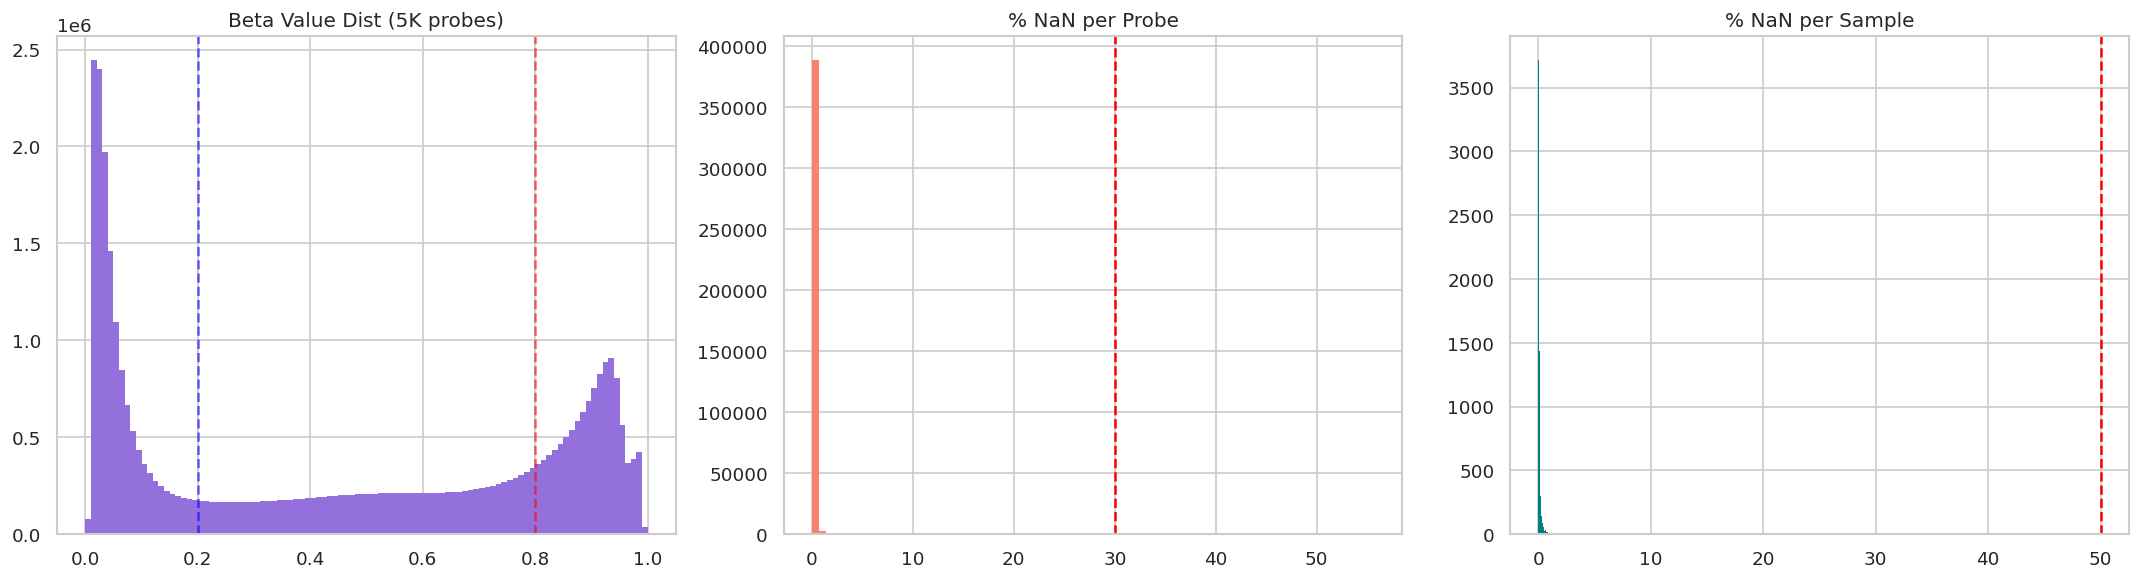


Slicing mRNA, CNV, Mut to common patients and genes...
Imputing 1,194,901 mRNA NaN values with gene-wise mean...
Removing bottom 10% lowest-variance mRNA genes...

─── FINAL ALIGNED SHAPES ───
  [mRNA final] RAM usage: 491.0 MB | shape: (7551, 16241)
  [CNV final] RAM usage: 123.1 MB | shape: (7551, 16241)
  [Mutation final] RAM usage: 123.1 MB | shape: (7551, 16241)
  [Methylation final] RAM usage: 11954.3 MB | shape: (7551, 395769)


In [6]:
section('5 & 6 & 7. METHYLATION CHUNKING, ALIGNMENT & PREPROCESSING')

if not INCLUDE_METHYLATION:
    print('Skipping methylation (INCLUDE_METHYLATION=False)')
    valid_patients_meth = set()
    METH_LOADED = False
else:
    print(f'Loading 450K methylation in chunks of {METH_CHUNK_SIZE:,} probes...')
    print(f'Using Memory-Safe Intersect-Then-Stitch mode.\n')
    
    processed_chunks  = []
    probe_nan_records = []    
    probe_names_list  = []    
    sample_nan_totals = None  
    total_probes_seen = 0
    total_dropped     = 0
    total_kept        = 0

    try:
        reader = pd.read_csv(path_meth, sep='\t', index_col=0, chunksize=METH_CHUNK_SIZE)
        raw_sample_names = None

        # ─── PART A: CHUNKING & CLEANING ──────────────────────────────────────────
        for chunk_num, chunk in enumerate(reader):
            total_probes_seen += len(chunk)
            if raw_sample_names is None:
                raw_sample_names = chunk.columns.copy()

            # Track NaNs
            chunk_nan = chunk.isna().sum(axis=0)
            if sample_nan_totals is None:
                sample_nan_totals = chunk_nan.copy()
            else:
                sample_nan_totals = sample_nan_totals.add(chunk_nan, fill_value=0)

            probe_nan_frac = chunk.isna().mean(axis=1)
            probe_nan_records.append(probe_nan_frac)

            # Drop bad probes
            keep_mask = probe_nan_frac <= PROBE_NAN_THRESH
            total_dropped += (~keep_mask).sum()
            chunk = chunk.loc[keep_mask]

            if len(chunk) == 0: continue

            # Impute Median
            if chunk.isna().any().any():
                chunk = chunk.apply(lambda row: row.fillna(row.median()), axis=1)

            # Downcast & Save NPZ
            chunk = chunk.astype(np.float32)
            chunk_vals = chunk.values.T  
            probe_names_list.extend(chunk.index.astype(str).tolist())
            
            chunk_path = f'meth_temp_chunk_{chunk_num}.npz'
            np.savez_compressed(chunk_path, data=chunk_vals)
            processed_chunks.append(chunk_path)
            total_kept += chunk_vals.shape[1]

            if (chunk_num + 1) % 5 == 0:
                print(f'  Chunk {chunk_num+1}: scanned {total_probes_seen:,} probes | kept {total_kept:,}')
            
            del chunk, chunk_vals; gc.collect()

        # ─── PART B: EARLY PATIENT ALIGNMENT ──────────────────────────────────────
        # Figure out who the valid methylation patients are
        sample_nan_frac = sample_nan_totals / total_probes_seen
        keep_samples = sample_nan_frac[sample_nan_frac <= SAMPLE_NAN_THRESH].index
        
        valid_nan_mask = raw_sample_names.isin(keep_samples)
        cleaned_names = raw_sample_names.str[:15]
        unique_mask = ~pd.Index(cleaned_names).duplicated(keep='first')
        
        valid_patients_meth = set(cleaned_names[valid_nan_mask & unique_mask])
        METH_LOADED = True
        
        # Calculate the final multi-omics intersection BEFORE allocating the big array!
        sets = {'Phenotype': valid_patients_pheno, 'mRNA': valid_patients_mrna,
                'CNV': valid_patients_cnv, 'Mutation': valid_patients_mut, 
                'Methylation': valid_patients_meth}
        
        print('\nPatient counts per modality:')
        for k, n in {k: len(v) for k, v in sets.items()}.items(): print(f'  {k:<15}: {n:,}')

        common_patients = sorted(set.intersection(*sets.values()))
        common_genes = sorted(valid_genes_mrna & valid_genes_cnv & valid_genes_mut)
        print(f'\nFinal intersection: {len(common_patients):,} patients')
        print(f'Common genes (mRNA∩CNV∩Mut): {len(common_genes):,}')

        # ─── PART C: DIRECT STITCHING OF ALIGNED MATRIX ───────────────────────────
        print(f'\nStitching chunks directly into final {len(common_patients)} patient array...')
        
        # Map the common_patients to their integer row index in the raw chunks
        idx_series = pd.Series(np.arange(len(cleaned_names)), index=cleaned_names)
        idx_series = idx_series[valid_nan_mask & unique_mask]
        row_indices = idx_series.loc[common_patients].values
        
        # Pre-allocate array (~11.9 GB instead of 15.3 GB)
        meth_array = np.empty((len(common_patients), total_kept), dtype=np.float32)
        
        col_idx = 0
        for chunk_path in processed_chunks:
            with np.load(chunk_path) as npz:
                c = npz['data']
            # Pluck out ONLY the common patients in perfectly sorted order!
            meth_array[:, col_idx : col_idx + c.shape[1]] = c[row_indices, :]
            col_idx += c.shape[1]
            os.remove(chunk_path)
            gc.collect()
            
        meth = pd.DataFrame(meth_array, index=common_patients, columns=probe_names_list)
        del meth_array; gc.collect()
        
        # ─── METHYLATION EDA PLOTS ────────────────────────────────────────────────
        all_probe_nans = pd.concat(probe_nan_records)
        del probe_nan_records
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sample_probes = np.random.choice(meth.columns, size=min(5000, meth.shape[1]), replace=False)
        vals = meth[sample_probes].values.flatten()
        vals = vals[~np.isnan(vals)]
        axes[0].hist(vals, bins=100, color='mediumpurple', edgecolor='none')
        axes[0].set_title('Beta Value Dist (5K probes)')
        axes[0].axvline(0.2, color='blue', linestyle='--', alpha=0.6)
        axes[0].axvline(0.8, color='red',  linestyle='--', alpha=0.6)

        axes[1].hist(all_probe_nans * 100, bins=80, color='salmon', edgecolor='none')
        axes[1].axvline(PROBE_NAN_THRESH * 100, color='red', linestyle='--', label='Dropped')
        axes[1].set_title('% NaN per Probe')

        axes[2].hist(sample_nan_frac * 100, bins=60, color='teal', edgecolor='none')
        axes[2].axvline(SAMPLE_NAN_THRESH * 100, color='red', linestyle='--', label='Dropped')
        axes[2].set_title('% NaN per Sample')
        
        plt.tight_layout(); plt.show()

    except FileNotFoundError:
        print(f'WARNING: File not found: {path_meth}')
        valid_patients_meth = set()
        METH_LOADED = False
        INCLUDE_METHYLATION = False

# ─── PART D: SLICE & PREPROCESS OTHER MODALITIES ──────────────────────────────
print('\nSlicing mRNA, CNV, Mut to common patients and genes...')
mrna   = mrna.loc[common_patients, common_genes]
cnv    = cnv.loc[common_patients, common_genes]
mut    = mut.loc[common_patients, common_genes]
labels = pheno.loc[common_patients, ['_primary_disease']]

nan_before = mrna.isnull().sum().sum()
if nan_before > 0:
    print(f'Imputing {nan_before:,} mRNA NaN values with gene-wise mean...')
    mrna = mrna.fillna(mrna.mean(axis=0))

print(f'Removing bottom {MRNA_VAR_QUANTILE*100:.0f}% lowest-variance mRNA genes...')
gene_var   = mrna.var(axis=0)
keep_genes = gene_var[gene_var > gene_var.quantile(MRNA_VAR_QUANTILE)].index

mrna = mrna[keep_genes].astype(np.float32)
cnv  = cnv[keep_genes]
mut  = mut[keep_genes]

print('\n─── FINAL ALIGNED SHAPES ───')
mem_usage(mrna, 'mRNA final')
mem_usage(cnv,  'CNV final')
mem_usage(mut,  'Mutation final')
if INCLUDE_METHYLATION and METH_LOADED:
    mem_usage(meth, 'Methylation final')


═════════════════════════════════════════════════════════════════
  8. FINAL COMBINED DATASET EDA
═════════════════════════════════════════════════════════════════


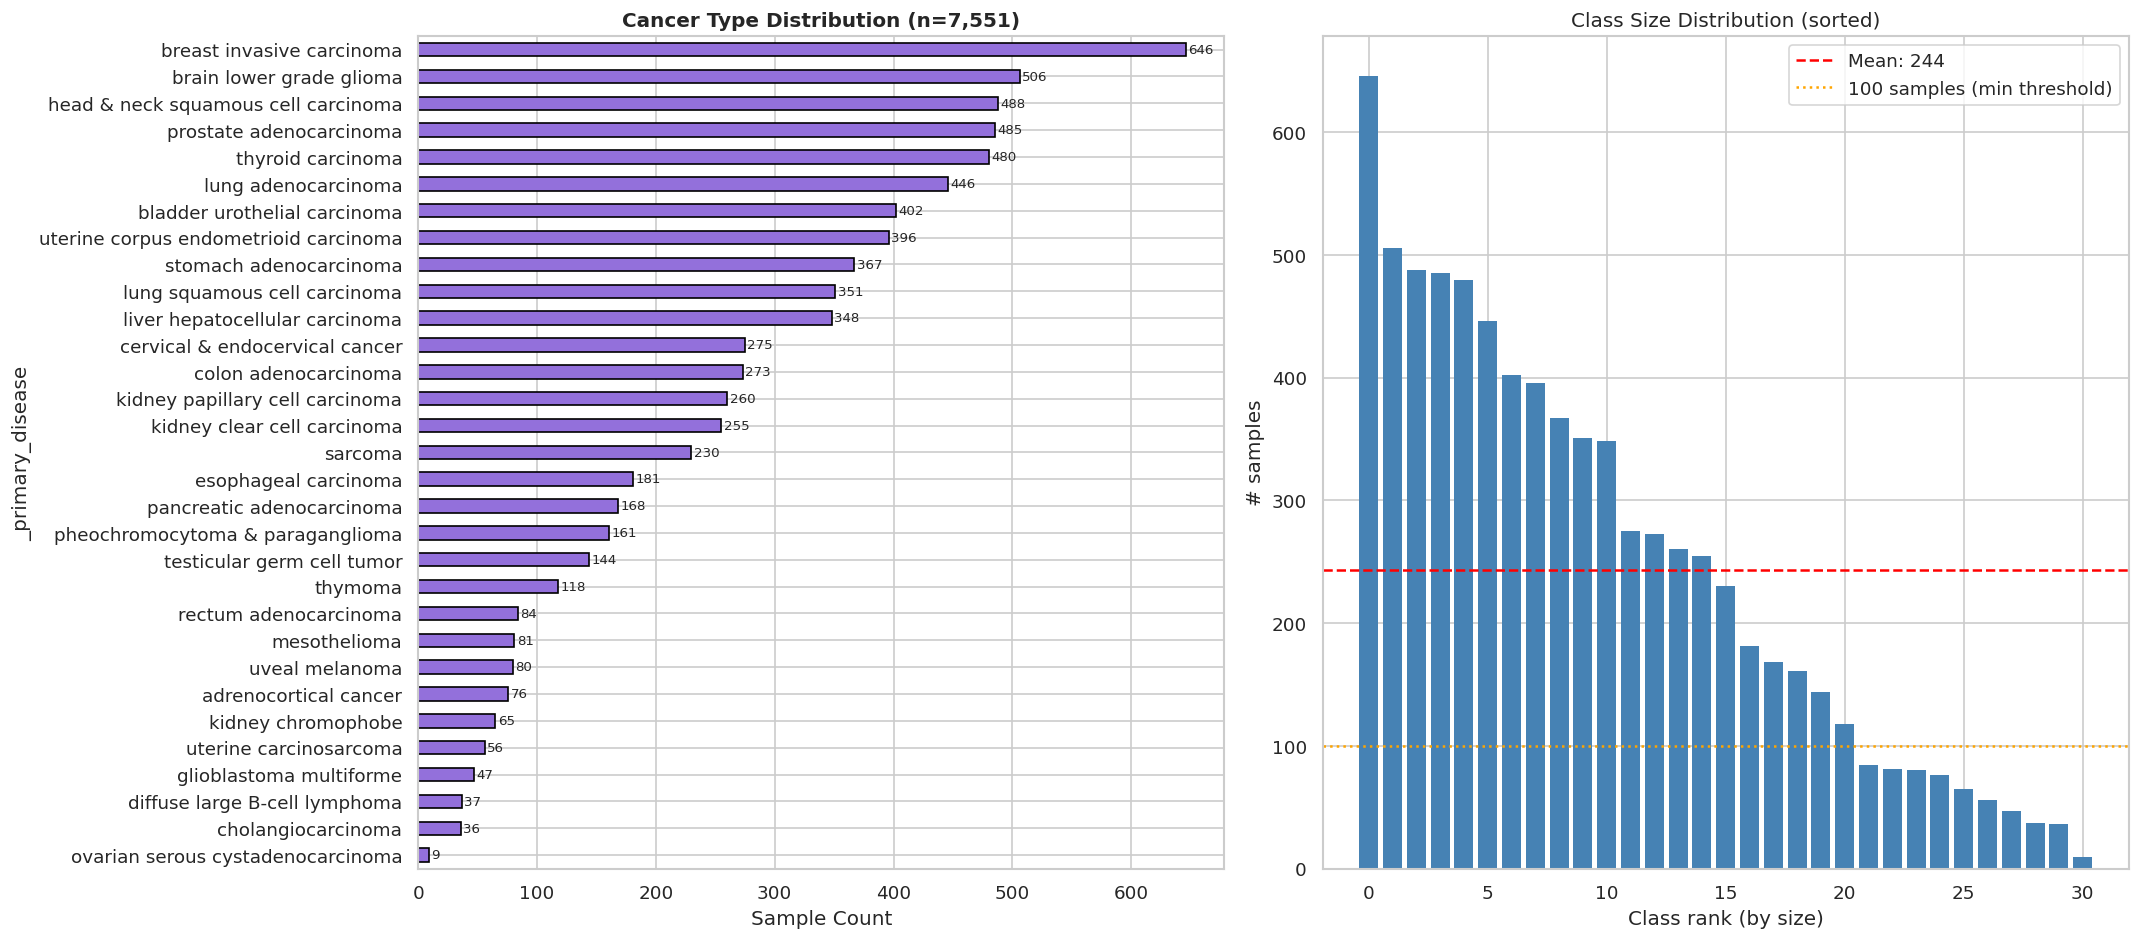

Class statistics:
  Largest class:  646 (breast invasive carcinoma)
  Smallest class: 9 (ovarian serous cystadenocarcinoma)
  Imbalance ratio: 71.8x
  Classes < 100 samples: 10

─── Cross-modality overlap summary ───
  mRNA        : 11,060 total → 9,701 w/phenotype → 7,551 in final
  CNV         : 10,845 total → 10,286 w/phenotype → 7,551 in final
  Mutation    : 9,104 total → 8,741 w/phenotype → 7,551 in final
  Methylation : 9,639 total → 7,551 in final


In [7]:
section('8. FINAL COMBINED DATASET EDA')

# ── Class distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
class_counts = labels['_primary_disease'].value_counts()
class_counts.plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title(f'Cancer Type Distribution (n={len(common_patients):,})', fontweight='bold')
axes[0].set_xlabel('Sample Count'); axes[0].invert_yaxis()
for i, (val, idx) in enumerate(zip(class_counts.values, class_counts.index)):
    axes[0].text(val + 2, i, str(val), va='center', fontsize=8)

# ── Class imbalance metric ────────────────────────────────────────────────
axes[1].bar(range(len(class_counts)), class_counts.values, color='steelblue', edgecolor='none')
axes[1].axhline(class_counts.mean(), color='red', linestyle='--', label=f'Mean: {class_counts.mean():.0f}')
axes[1].axhline(100, color='orange', linestyle=':', label='100 samples (min threshold)')
axes[1].set_title('Class Size Distribution (sorted)')
axes[1].set_xlabel('Class rank (by size)'); axes[1].set_ylabel('# samples')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Class statistics:')
print(f'  Largest class:  {class_counts.max():,} ({class_counts.idxmax()})')
print(f'  Smallest class: {class_counts.min():,} ({class_counts.idxmin()})')
print(f'  Imbalance ratio: {class_counts.max() / class_counts.min():.1f}x')
print(f'  Classes < 100 samples: {(class_counts < 100).sum()}')

# ── Cross-modality patient overlap Venn (text-based) ─────────────────────
print('\n─── Cross-modality overlap summary ───')
base_mods = ['mRNA', 'CNV', 'Mutation']
base_sets_final = [valid_patients_mrna, valid_patients_cnv, valid_patients_mut]
for i, (n, s) in enumerate(zip(base_mods, base_sets_final)):
    overlap = len(s & valid_patients_pheno)
    in_final = len(s & set(common_patients))
    print(f'  {n:<12}: {len(s):,} total → {overlap:,} w/phenotype → {in_final:,} in final')
if INCLUDE_METHYLATION and METH_LOADED:
    in_final_m = len(valid_patients_meth & set(common_patients))
    print(f'  {"Methylation":<12}: {len(valid_patients_meth):,} total → {in_final_m:,} in final')


In [8]:
section('9. SAVING OUTPUT FILES')

# Ensure string columns (required for parquet)
mrna.columns = mrna.columns.astype(str)
cnv.columns  = cnv.columns.astype(str)
mut.columns  = mut.columns.astype(str)

print('Saving parquet files (fast, compressed, preserves dtypes)...')
mrna.to_parquet('mrna_final.parquet');   print('  mrna_final.parquet ✅')
cnv.to_parquet('cnv_final.parquet');     print('  cnv_final.parquet  ✅')
mut.to_parquet('mut_final.parquet');     print('  mut_final.parquet  ✅')
labels.to_parquet('labels_final.parquet'); print('  labels_final.parquet ✅')

if INCLUDE_METHYLATION and METH_LOADED:
    meth.columns = meth.columns.astype(str)
    meth.to_parquet('meth_final.parquet')
    print('  meth_final.parquet ✅')

print('\n─── Summary of saved files ───')
print(f'  mrna_final.parquet    — {mrna.shape[0]:,} patients × {mrna.shape[1]:,} genes | float32')
print(f'  cnv_final.parquet     — {cnv.shape[0]:,} patients × {cnv.shape[1]:,} genes | int8')
print(f'  mut_final.parquet     — {mut.shape[0]:,} patients × {mut.shape[1]:,} genes | int8')
if INCLUDE_METHYLATION and METH_LOADED:
    print(f'  meth_final.parquet    — {meth.shape[0]:,} patients × {meth.shape[1]:,} probes | float32')
print(f'  labels_final.parquet  — {labels.shape[0]:,} patients × 1 label column')

print('\n─── Next steps ───')
print('  1. Upload all parquet files to your Kaggle dataset')
print('  2. In OncoBridge training notebook:')
print('     - Set active_modalities = ["mrna", "cnv", "mut"] for 3-modality run')
print('     - Set active_modalities = ["mrna", "cnv", "mut", "meth"] for 4-modality run')
print('  3. Note: methylation intersection will reduce n from', len(common_patients),
      'to ~', len(common_patients) if not METH_LOADED else
      len(set(common_patients) & valid_patients_meth))
print('\nAll processing complete ✅')



═════════════════════════════════════════════════════════════════
  9. SAVING OUTPUT FILES
═════════════════════════════════════════════════════════════════
Saving parquet files (fast, compressed, preserves dtypes)...
  mrna_final.parquet ✅
  cnv_final.parquet  ✅
  mut_final.parquet  ✅
  labels_final.parquet ✅
  meth_final.parquet ✅

─── Summary of saved files ───
  mrna_final.parquet    — 7,551 patients × 16,241 genes | float32
  cnv_final.parquet     — 7,551 patients × 16,241 genes | int8
  mut_final.parquet     — 7,551 patients × 16,241 genes | int8
  meth_final.parquet    — 7,551 patients × 395,769 probes | float32
  labels_final.parquet  — 7,551 patients × 1 label column

─── Next steps ───
  1. Upload all parquet files to your Kaggle dataset
  2. In OncoBridge training notebook:
     - Set active_modalities = ["mrna", "cnv", "mut"] for 3-modality run
     - Set active_modalities = ["mrna", "cnv", "mut", "meth"] for 4-modality run
  3. Note: methylation intersection will reduce n